In [ ]:
##Six years of Irish drinks exports from Bord Bia (2019 to 2024). Every figure checked against the primary reports. Figures marked estimated where a report did not print an exact number.
import pandas as pd

data = {
    'Year':                [2019, 2020, 2021, 2022, 2023, 2024],
    'Total_Drinks_EUR_M':  [1600.8, 1297.3, 1620.0, 2000.0, 1800.0, 2100.0],
    'Whiskey_EUR_M':       [825, 620, 855, 1000, 875, 1000],
    'Cream_Liqueur_EUR_M': [364, 311, 367, 448, 370, 380],   # 2022 = €448m per 2022-23 report
    'Beer_EUR_M':          [305, 254, 246, 298, 330, 325],    # 2022 beer estimated (chart only)
    'Total_Quality':       ['exact','exact','exact','approx','exact','exact'],
}

df = pd.DataFrame(data)
df['Total_YoY_Pct']   = df['Total_Drinks_EUR_M'].pct_change() * 100
df['Whiskey_YoY_Pct'] = df['Whiskey_EUR_M'].pct_change() * 100

print(df.to_string(index=False))

 Year  Total_Drinks_EUR_M  Whiskey_EUR_M  Cream_Liqueur_EUR_M  Beer_EUR_M Total_Quality  Total_YoY_Pct  Whiskey_YoY_Pct
 2019              1600.8            825                  364         305         exact            NaN              NaN
 2020              1297.3            620                  311         254         exact     -18.959270       -24.848485
 2021              1620.0            855                  367         246         exact      24.874740        37.903226
 2022              2000.0           1000                  448         298        approx      23.456790        16.959064
 2023              1800.0            875                  370         330         exact     -10.000000       -12.500000
 2024              2100.0           1000                  380         325         exact      16.666667        14.285714


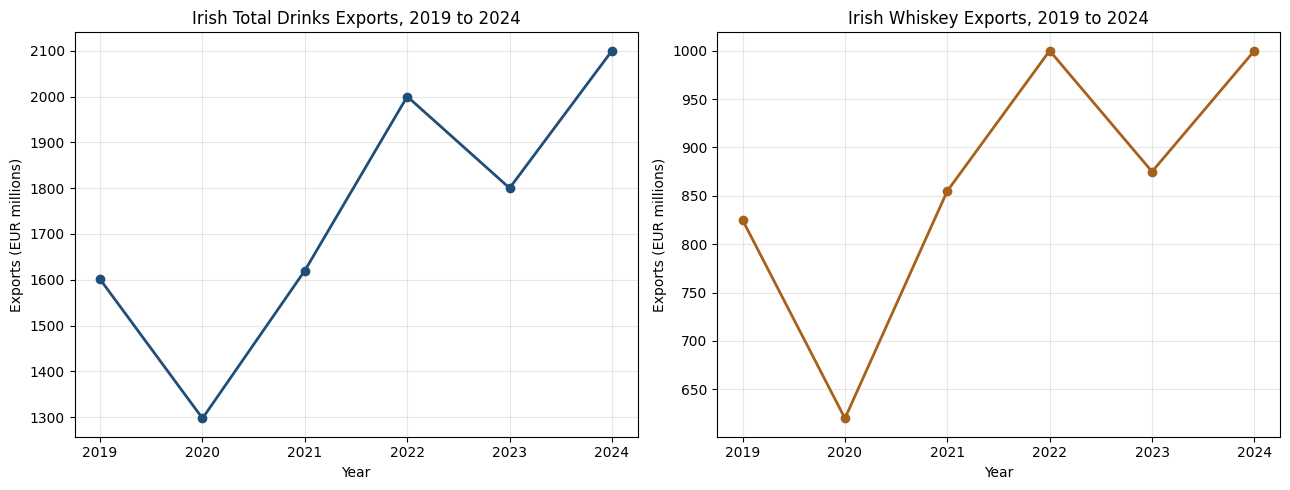

In [ ]:
##Line charts showing how total drinks exports and whiskey exports moved from 2019 to 2024.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Total drinks exports over time
ax[0].plot(df['Year'], df['Total_Drinks_EUR_M'], marker='o', linewidth=2, color='#1f4e79')
ax[0].set_title('Irish Total Drinks Exports, 2019 to 2024')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Exports (EUR millions)')
ax[0].grid(True, alpha=0.3)

# Chart 2: Whiskey exports over time
ax[1].plot(df['Year'], df['Whiskey_EUR_M'], marker='o', linewidth=2, color='#a6611a')
ax[1].set_title('Irish Whiskey Exports, 2019 to 2024')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Exports (EUR millions)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


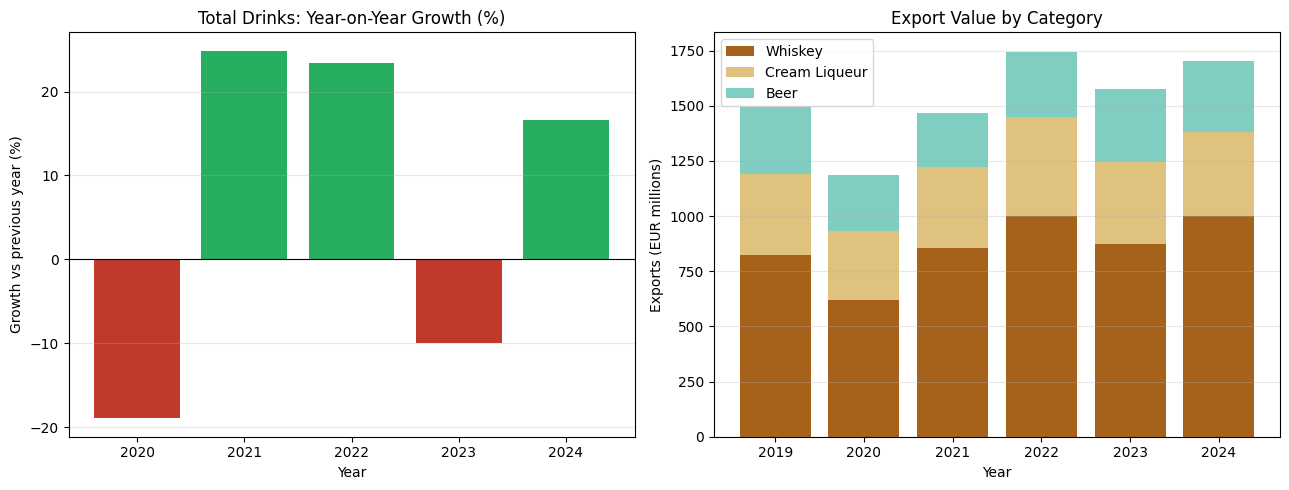

In [ ]:
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Chart 3: Year-on-year growth of total drinks (bar chart)
colors = ['grey' if np.isnan(v) else ('#c0392b' if v < 0 else '#27ae60')
          for v in df['Total_YoY_Pct']]
ax[0].bar(df['Year'], df['Total_YoY_Pct'], color=colors)
ax[0].axhline(0, color='black', linewidth=0.8)
ax[0].set_title('Total Drinks: Year-on-Year Growth (%)')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Growth vs previous year (%)')
ax[0].grid(True, axis='y', alpha=0.3)

# Chart 4: Category split over time (stacked bars)
ax[1].bar(df['Year'], df['Whiskey_EUR_M'], label='Whiskey', color='#a6611a')
ax[1].bar(df['Year'], df['Cream_Liqueur_EUR_M'], bottom=df['Whiskey_EUR_M'],
          label='Cream Liqueur', color='#dfc27d')
ax[1].bar(df['Year'], df['Beer_EUR_M'],
          bottom=df['Whiskey_EUR_M'] + df['Cream_Liqueur_EUR_M'],
          label='Beer', color='#80cdc1')
ax[1].set_title('Export Value by Category')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Exports (EUR millions)')
ax[1].legend()
ax[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Forecast, total drinks exports (EUR millions):
2025    2171.5
2026    2294.2
dtype: float64


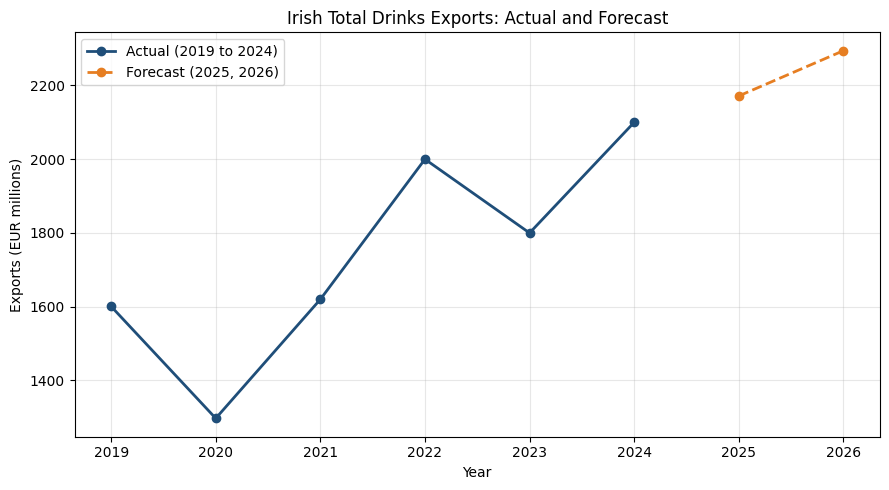

In [ ]:
##Holt's linear trend method (damped) on the total drinks series. With only six annual points this is a directional projection, not a precise prediction.
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Total drinks as a yearly series, indexed by year
series = df.set_index('Year')['Total_Drinks_EUR_M']

# Holt's linear trend, damped (no seasonality: only 6 annual points)
model = ExponentialSmoothing(series, trend='add', damped_trend=True, seasonal=None)
fit = model.fit()

forecast = fit.forecast(2)
forecast.index = [2025, 2026]

print("Forecast, total drinks exports (EUR millions):")
print(forecast.round(1))

# Plot actual history plus the forecast
plt.figure(figsize=(9, 5))
plt.plot(series.index, series.values, marker='o', linewidth=2,
         color='#1f4e79', label='Actual (2019 to 2024)')
plt.plot(forecast.index, forecast.values, marker='o', linewidth=2,
         linestyle='--', color='#e67e22', label='Forecast (2025, 2026)')
plt.title('Irish Total Drinks Exports: Actual and Forecast')
plt.xlabel('Year')
plt.ylabel('Exports (EUR millions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
##Feed the verified figures and the forecast to Claude, and get back a short plain-language summary. The prompt forbids inventing numbers and forbids em dashes.

!pip install anthropic -q

from google.colab import userdata
import anthropic

client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))

# Hand the model only the verified data and the forecast
data_summary = df.to_string(index=False)
forecast_summary = f"2025: {forecast[2025]:.0f}, 2026: {forecast[2026]:.0f}"

prompt = f"""You are a data analyst writing a short, plain-language business summary of Irish drinks export data. Use only the figures provided. Do not invent any numbers. Note that 2022 figures are approximate and that the forecast is directional, not precise.

Data (EUR millions):
{data_summary}

Forecast of total drinks exports (EUR millions): {forecast_summary}

Write three short paragraphs: (1) what happened from 2019 to 2024, (2) the whiskey story specifically, (3) the outlook, including a clear caveat about the short data series. Do not use em dashes. Use commas or full stops instead."""

message = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=600,
    messages=[{"role": "user", "content": prompt}],
)

print(message.content[0].text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.9/956.9 kB 23.4 MB/s eta 0:00:00
## Irish Drinks Exports: A Summary

Irish drinks exports showed strong underlying growth between 2019 and 2024, though the path was far from smooth. Total exports stood at approximately EUR 1.6 billion in 2019 before falling sharply to EUR 1.3 billion in 2020, a drop of around 19%, largely reflecting the disruption to on-trade and travel retail during the pandemic. A strong rebound followed, with exports climbing back through 2021 and reaching an approximate EUR 2.0 billion in 2022. A pullback to EUR 1.8 billion in 2023 interrupted that momentum, but 2024 saw exports recover to EUR 2.1 billion, a gain of around 17% on the prior year and the highest level in the series. Beer held broadly steady across the period, finishing at EUR 325 million in 2024, while cream liqueur grew from EUR 364 million to EUR 380 million.

Whiskey is the single largest category and has driven much of the overall story. From a 2019

In [ ]:
## Build one tidy table: actuals + forecast, marked with a Type column
actual = df.copy()
actual['Type'] = 'Actual'

fc = pd.DataFrame({
    'Year': [2025, 2026],
    'Total_Drinks_EUR_M': [round(forecast[2025], 1), round(forecast[2026], 1)],
    'Total_Quality': ['forecast', 'forecast'],
    'Type': ['Forecast', 'Forecast'],
})

combined = pd.concat([actual, fc], ignore_index=True)

# Save three files
combined.to_csv('irish_drinks_analysis.csv', index=False)
df.to_excel('irish_drinks_data.xlsx', index=False)
with open('ai_insight_summary.txt', 'w') as f:
    f.write(message.content[0].text)

print("Files saved:")
print(combined.to_string(index=False))

# Download them to your computer
from google.colab import files
files.download('irish_drinks_analysis.csv')
files.download('irish_drinks_data.xlsx')
files.download('ai_insight_summary.txt')


Files saved:
 Year  Total_Drinks_EUR_M  Whiskey_EUR_M  Cream_Liqueur_EUR_M  Beer_EUR_M Total_Quality  Total_YoY_Pct  Whiskey_YoY_Pct     Type
 2019              1600.8          825.0                364.0       305.0         exact            NaN              NaN   Actual
 2020              1297.3          620.0                311.0       254.0         exact     -18.959270       -24.848485   Actual
 2021              1620.0          855.0                367.0       246.0         exact      24.874740        37.903226   Actual
 2022              2000.0         1000.0                448.0       298.0        approx      23.456790        16.959064   Actual
 2023              1800.0          875.0                370.0       330.0         exact     -10.000000       -12.500000   Actual
 2024              2100.0         1000.0                380.0       325.0         exact      16.666667        14.285714   Actual
 2025              2171.5            NaN                  NaN         NaN      forec

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>